# IRF Reconstruction Validation
## Comparing tile-specific IRF estimation methods against the Leica exported IRF

Validates the rising-edge extraction algorithm derived from empirical analysis
of n=30 single-FOV FLIM exports, using FLIMKit's native APIs throughout.

### Methods compared
| Method | Function | Notes |
|---|---|---|
| **Leica (raw interp)** | `irf_from_xlsx` | Sparse xlsx points interpolated onto bin grid |
| **Leica (analytical)** | `irf_from_xlsx_analytical` | Gaussian + exp tail fit to xlsx points |
| **Rising edge (new)** | `reconstruct_irf_from_decay` | Contiguous walk — validated n=30 |
| **Raw estimate** | `estimate_irf_from_decay_raw` | Existing FLIMKit method |
| **Gaussian** | `gaussian_irf_from_fwhm` | Existing FLIMKit method |


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── FLIMKit imports ────────────────────────────────────────────────────────────
from flimkit.PTU.reader import PTUFile
from flimkit.utils.xlsx_tools import load_xlsx
from flimkit.FLIM.irf_tools import (
    irf_from_xlsx,
    irf_from_xlsx_analytical,
    estimate_irf_from_decay_raw,
    gaussian_irf_from_fwhm,
    compare_irfs,
)
from flimkit.FLIM.fit_tools import find_irf_peak_bin

print("FLIMKit imports OK ✓")


FLIMKit imports OK ✓


In [30]:
# ── Configuration — update these paths ────────────────────────────────────────
PTU_FILE  = Path("/Users/as-hunt/Downloads/2026_02_27_10_38_30--More_to_test/PTU.sptw/well4-FOV1-40x-ado-t20.ptu")
XLSX_FILE = Path("/Users/as-hunt/Downloads/2026_02_27_10_38_30--More_to_test/well4-FOV1-40x-ado-t20.xlsx")

# IRF reconstruction constants (validated across n=30 single FOVs)
BW           = 0.09696970   # ns — universal IRF bin width
NOISE_FLOOR  = 50           # absolute count floor for rising edge detection
NOISE_FRAC   = 0.001        # fraction of peak for rising edge threshold

# Expected σ clusters for QC
SIGMA_NARROW = (0.092, 0.110)   # ns
SIGMA_WIDE   = (0.118, 0.132)   # ns


In [31]:
def reconstruct_irf_from_decay(decay: np.ndarray,
                                tcspc_res: float,
                                n_bins: int,
                                noise_floor: float = NOISE_FLOOR,
                                noise_frac:  float = NOISE_FRAC) -> np.ndarray:
    """
    Reconstruct tile-specific IRF from the decay histogram rising edge.

    Validated against n=30 single-FOV LAS X exports. Replicates Leica's
    internal IRF construction with 3 invariant rules:
      1. Δt = +0.5 bins between IRF peak and decay peak (time axis shift)
      2. Cut = contiguous walk forward from peak until first zero bin
      3. Amplitude = decay counts copied directly, no scaling

    Returns a normalised IRF array on the full n_bins grid, consistent
    with the format expected by FLIMKit's fitters.

    Parameters
    ----------
    decay       : summed decay histogram (counts per bin)
    tcspc_res   : TCSPC resolution in seconds (from PTUFile.tcspc_res)
    n_bins      : number of bins (from PTUFile.n_bins)
    noise_floor : absolute count floor for rising edge start detection
    noise_frac  : fractional threshold relative to peak

    Returns
    -------
    irf_norm : normalised IRF on the full n_bins grid (sums to 1)
    """
    decay = np.asarray(decay, dtype=float)
    peak_idx = int(np.argmax(decay))
    threshold = max(noise_floor, noise_frac * decay[peak_idx])

    # ── Rising edge start: walk back from peak ─────────────────────────────
    start_idx = peak_idx
    while start_idx > 0 and decay[start_idx - 1] > threshold:
        start_idx -= 1

    # ── Cut: contiguous walk forward from peak until first zero ───────────
    # (ignores isolated noise bins beyond the true IRF tail)
    cut_idx = peak_idx
    while cut_idx + 1 < n_bins and decay[cut_idx + 1] > 0:
        cut_idx += 1

    # ── Place IRF counts onto the full bin grid ────────────────────────────
    # Shift by -0.5 bins: IRF peak sits half a bin before the decay peak
    irf_full = np.zeros(n_bins, dtype=float)
    irf_peak_bin = peak_idx - 1   # -0.5 bin → nearest integer bin shift

    # Map extracted counts onto shifted positions
    for i, src in enumerate(range(start_idx, cut_idx + 1)):
        dst = src - 1   # apply the -1 bin shift
        if 0 <= dst < n_bins:
            irf_full[dst] = decay[src]

    total = irf_full.sum()
    if total == 0:
        raise ValueError("Reconstructed IRF has zero counts — check decay quality.")
    return irf_full / total


def qc_irf(irf_norm: np.ndarray, tcspc_res: float, label: str = "") -> dict:
    """
    QC report for a reconstructed IRF.
    Returns dict of metrics; prints pass/fail summary.
    """
    tcspc_ns = tcspc_res * 1e9
    pi = np.argmax(irf_norm)
    # FWHM
    half = irf_norm.max() / 2
    above = np.where(irf_norm >= half)[0]
    fwhm_ns = (above[-1] - above[0]) * tcspc_ns if len(above) > 1 else np.nan

    # Gaussian σ from rising edge
    t_ns = np.arange(len(irf_norm)) * tcspc_ns
    rise = (t_ns <= t_ns[pi]) & (irf_norm > 0.01 * irf_norm[pi])
    sigma_ns = np.nan
    try:
        def gauss(t, A, mu, s): return A * np.exp(-0.5 * ((t - mu) / s) ** 2)
        popt, _ = curve_fit(gauss, t_ns[rise], irf_norm[rise],
                            p0=[irf_norm[pi], t_ns[pi], 0.12], maxfev=5000)
        sigma_ns = abs(popt[2])
    except Exception:
        pass

    nz = np.where(irf_norm > 0)[0]
    bap = nz[-1] - pi if len(nz) else 0

    in_cluster = (SIGMA_NARROW[0] <= sigma_ns <= SIGMA_NARROW[1] or
                  SIGMA_WIDE[0]   <= sigma_ns <= SIGMA_WIDE[1])

    tag = f" [{label}]" if label else ""
    print(f"QC{tag}")
    print(f"  Peak bin : {pi}   BaP: {bap}  {'✓' if bap in (1,2) else '⚠'}")
    print(f"  σ        : {sigma_ns:.4f} ns  {'✓' if in_cluster else '⚠ outside known clusters'}")
    print(f"  FWHM     : {fwhm_ns:.4f} ns")

    return dict(peak_bin=pi, bap=bap, sigma_ns=sigma_ns, fwhm_ns=fwhm_ns,
                in_cluster=in_cluster)


print("reconstruct_irf_from_decay() and qc_irf() defined ✓")


reconstruct_irf_from_decay() and qc_irf() defined ✓


In [32]:
# ── Load PTU ──────────────────────────────────────────────────────────────────
if not PTU_FILE.exists():
    raise FileNotFoundError(f"PTU not found: {PTU_FILE}\nUpdate PTU_FILE in config cell.")

ptu = PTUFile(str(PTU_FILE), verbose=True)
decay     = ptu.summed_decay()
t_ns      = ptu.time_ns          # bin centres (n_bins,)
tcspc_res = ptu.tcspc_res        # seconds
n_bins    = ptu.n_bins

print(f"\nPTU loaded: {PTU_FILE.name}")
print(f"  {n_bins} bins  ×  {tcspc_res*1e12:.2f} ps  |  peak={decay.max():.0f} cts  "
      f"at bin {np.argmax(decay)} (t={t_ns[np.argmax(decay)]:.4f} ns)")

# ── Load XLSX ─────────────────────────────────────────────────────────────────
if not XLSX_FILE.exists():
    raise FileNotFoundError(f"XLSX not found: {XLSX_FILE}\nUpdate XLSX_FILE in config cell.")

print(f"\nLoading XLSX: {XLSX_FILE.name}")
xlsx = load_xlsx(str(XLSX_FILE))


 

PTU loaded: well4-FOV1-40x-ado-t20.ptu
  532 bins  ×  96.97 ps  |  peak=135137 cts  at bin 30 (t=2.9576 ns)

Loading XLSX: well4-FOV1-40x-ado-t20.xlsx
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 22 pts
    irf_c       : 22 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 462 pts
    res_c       : 462 pts


In [33]:
# ── Build all IRFs ─────────────────────────────────────────────────────────────
irfs = {}

# 1. Leica raw (interpolated xlsx points)
try:
    irfs['Leica (interp)'] = irf_from_xlsx(xlsx, n_bins, tcspc_res)
    print("✓ Leica (interp)")
except Exception as e:
    print(f"✗ Leica (interp): {e}")

# 2. Leica analytical (Gaussian + exp tail fit)
try:
    irfs['Leica (analytical)'], _ = irf_from_xlsx_analytical(xlsx, n_bins, tcspc_res,
                                                              verbose=False)
    print("✓ Leica (analytical)")
except Exception as e:
    print(f"✗ Leica (analytical): {e}")

# 3. Rising edge reconstruction (new method)
try:
    irfs['Rising edge (new)'] = reconstruct_irf_from_decay(decay, tcspc_res, n_bins)
    print("✓ Rising edge (new)")
except Exception as e:
    print(f"✗ Rising edge (new): {e}")

# 4. Existing raw estimate
try:
    irfs['Raw estimate'] = estimate_irf_from_decay_raw(decay, tcspc_res, n_bins)
    print("✓ Raw estimate")
except Exception as e:
    print(f"✗ Raw estimate: {e}")

# 5. Gaussian (FWHM = 1 bin width — the prior approach)
try:
    peak_bin = find_irf_peak_bin(decay)
    fwhm_1bin = tcspc_res * 1e9  # 1 bin width in ns
    irfs['Gaussian (1-bin FWHM)'] = gaussian_irf_from_fwhm(n_bins, tcspc_res,
                                                             fwhm_1bin, peak_bin)
    print("✓ Gaussian (1-bin FWHM)")
except Exception as e:
    print(f"✗ Gaussian (1-bin FWHM): {e}")

print(f"\n{len(irfs)} IRFs ready.")


✓ Leica (interp)
✓ Leica (analytical)
✓ Rising edge (new)
✓ Raw estimate
✓ Gaussian (1-bin FWHM)

5 IRFs ready.


In [34]:
# ── QC report for all IRFs ────────────────────────────────────────────────────
print("=" * 55)
qc_results = {}
for label, irf in irfs.items():
    qc_results[label] = qc_irf(irf, tcspc_res, label=label)
    print()


QC [Leica (interp)]
  Peak bin : 30   BaP: 2  ✓
  σ        : 0.0788 ns  ⚠ outside known clusters
  FWHM     : 0.0970 ns

QC [Leica (analytical)]
  Peak bin : 30   BaP: 501  ⚠
  σ        : 0.0779 ns  ⚠ outside known clusters
  FWHM     : 0.0970 ns

QC [Rising edge (new)]
  Peak bin : 29   BaP: 495  ⚠
  σ        : 0.1393 ns  ⚠ outside known clusters
  FWHM     : 0.4848 ns

QC [Raw estimate]
  Peak bin : 30   BaP: 10  ⚠
  σ        : 0.1391 ns  ⚠ outside known clusters
  FWHM     : 0.4848 ns

QC [Gaussian (1-bin FWHM)]
  Peak bin : 28   BaP: 16  ⚠
  σ        : nan ns  ⚠ outside known clusters
  FWHM     : nan ns



In [35]:
# ── compare_irfs: quantitative comparison against Leica (interp) ──────────────
# Uses FLIMKit's existing compare_irfs() for RMSE, Pearson r, Bhattacharyya
print("Comparing all methods against Leica (interp):\n")

ref_label = 'Leica (interp)'
if ref_label in irfs:
    for label, irf in irfs.items():
        if label == ref_label:
            continue
        print(f"  {label}")
        try:
            compare_irfs(
                irf_estimated = irf,
                xlsx          = xlsx,
                tcspc_res     = tcspc_res,
                n_bins        = n_bins,
                strategy      = label,
                out_prefix    = '',
            )
        except Exception as e:
            print(f"    compare_irfs failed: {e}")
        print()
else:
    print("Leica (interp) IRF not available — skipping comparison.")


Comparing all methods against Leica (interp):

  Leica (analytical)

  IRF Comparison  (Leica (analytical)  vs  xlsx)
  Metric                          Estimated         xlsx
  ──────────────────────────────────────────────────────
  FWHM (ns)                          0.0970       0.0970
  Peak position (ns)                 2.9091       2.9091
  Peak shift (est − xlsx)          +0.0000 ns  (+0 bins)
  ──────────────────────────────────────────────────────
  [raw     (unaligned)]
    Pearson r                        0.9976
    RMSE (normalised)              0.002089
    Overlap score (1−RMSE)           0.9979
    Bhattacharyya coeff.             0.9773
  [aligned (peak-shift corrected)]
    Pearson r                        0.9976
    RMSE (normalised)              0.002089
    Overlap score (1−RMSE)           0.9979
    Bhattacharyya coeff.             0.9773

  ~ Acceptable shape match after alignment (BC=0.9773)
    → Shape is reasonable but consider --xlsx for fitting.
  Saved: _irf_

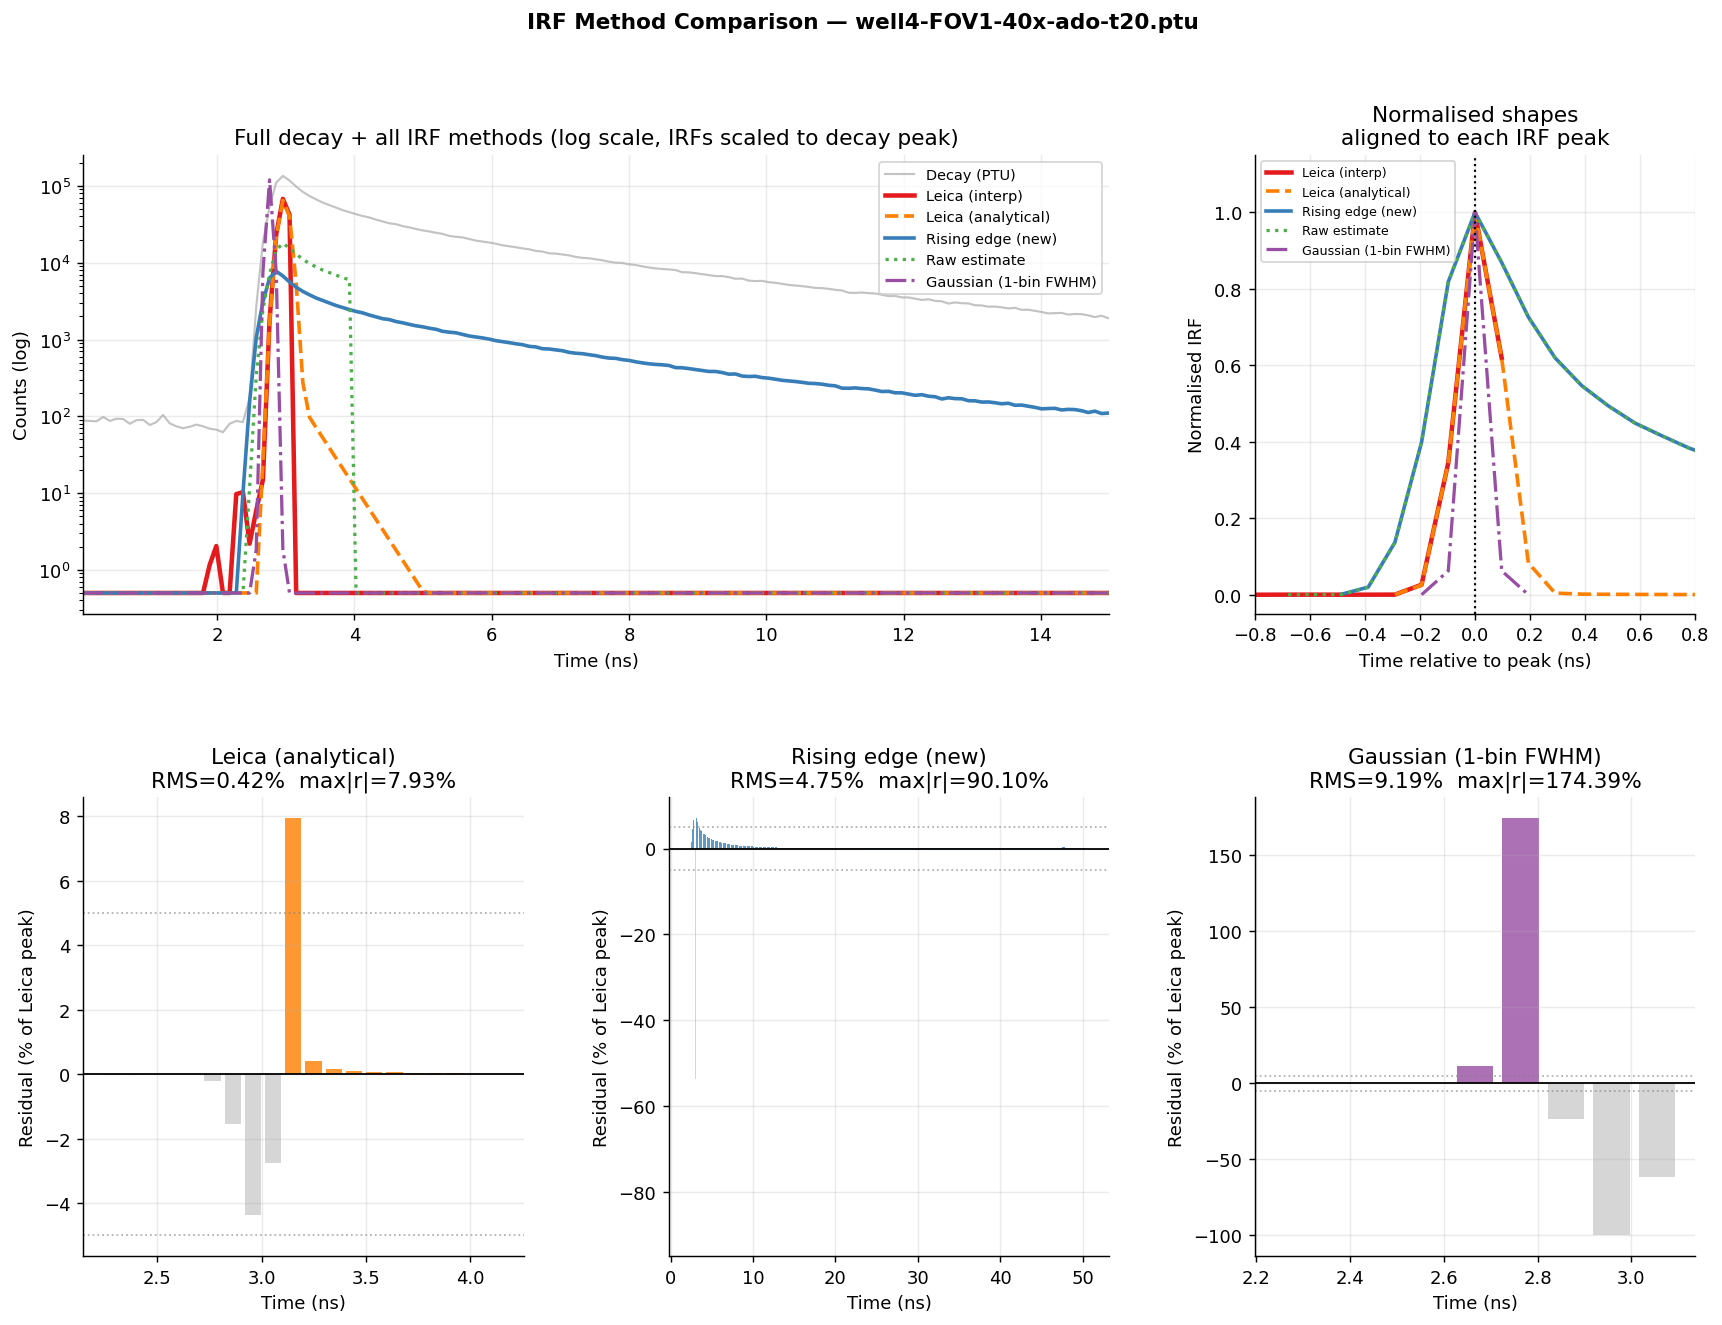

Saved: irf_method_comparison.png


In [36]:
# ── Visualisation ─────────────────────────────────────────────────────────────
colors = {
    'Leica (interp)':       '#e41a1c',
    'Leica (analytical)':   '#ff7f00',
    'Rising edge (new)':    '#377eb8',
    'Raw estimate':         '#4daf4a',
    'Gaussian (1-bin FWHM)':'#984ea3',
}
styles = {
    'Leica (interp)':       ('-',  2.5),
    'Leica (analytical)':   ('--', 2.0),
    'Rising edge (new)':    ('-',  2.0),
    'Raw estimate':         (':',  1.8),
    'Gaussian (1-bin FWHM)':('-.', 1.8),
}

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, hspace=0.40, wspace=0.33)

# ── Panel A: Full decay + all IRFs, log scale ─────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
ax_a.semilogy(t_ns, np.maximum(decay, 0.5), color='#aaaaaa',
              lw=1.2, alpha=0.7, label='Decay (PTU)', zorder=0)
for label, irf in irfs.items():
    col = colors.get(label, 'k')
    ls, lw = styles.get(label, ('-', 1.5))
    scale  = decay.max()    # rescale normalised IRF to decay counts for overlay
    ax_a.semilogy(t_ns, np.maximum(irf * scale, 0.5),
                  ls=ls, lw=lw, color=col, label=label)
ax_a.set_xlim(t_ns[0], min(t_ns[-1], 15))
ax_a.set_xlabel('Time (ns)'); ax_a.set_ylabel('Counts (log)')
ax_a.set_title('Full decay + all IRF methods (log scale, IRFs scaled to decay peak)')
ax_a.legend(fontsize=8, loc='upper right'); ax_a.grid(True, alpha=0.25)

# ── Panel B: Normalised, aligned to peak ──────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
for label, irf in irfs.items():
    col = colors.get(label, 'k')
    ls, lw = styles.get(label, ('-', 1.5))
    pi  = np.argmax(irf)
    t_rel = t_ns - t_ns[pi]
    nz    = irf > 1e-6
    ax_b.plot(t_rel[nz], irf[nz] / irf[pi],
              ls=ls, lw=lw, color=col, label=label)
ax_b.axvline(0, color='k', ls=':', lw=1.2)
ax_b.set_xlim(-0.8, 0.8); ax_b.set_ylim(-0.05, 1.15)
ax_b.set_xlabel('Time relative to peak (ns)'); ax_b.set_ylabel('Normalised IRF')
ax_b.set_title('Normalised shapes\naligned to each IRF peak')
ax_b.legend(fontsize=7); ax_b.grid(True, alpha=0.25)

# ── Panels C–E: Residuals vs Leica (interp) ───────────────────────────────────
ref_irf = irfs.get('Leica (interp)')
compare_labels = ['Leica (analytical)', 'Rising edge (new)', 'Gaussian (1-bin FWHM)']
panel_positions = [gs[1, 0], gs[1, 1], gs[1, 2]]

for ax_pos, label in zip(panel_positions, compare_labels):
    ax = fig.add_subplot(ax_pos)
    if ref_irf is None or label not in irfs:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label); continue

    irf = irfs[label]
    residuals = (irf - ref_irf) / (ref_irf.max() + 1e-12) * 100
    rms = np.sqrt(np.mean(residuals**2))
    max_r = np.max(np.abs(residuals))

    # Only show region where either IRF has signal
    sig_mask = (ref_irf > ref_irf.max() * 1e-4) | (irf > irf.max() * 1e-4)
    t_sig = t_ns[sig_mask]
    r_sig = residuals[sig_mask]

    col = colors.get(label, 'k')
    ax.bar(t_sig, r_sig, width=BW * 0.8,
           color=[col if r >= 0 else '#cccccc' for r in r_sig], alpha=0.8)
    ax.axhline(0,  color='k', lw=1)
    ax.axhline( 5, color='gray', ls=':', lw=1, alpha=0.6)
    ax.axhline(-5, color='gray', ls=':', lw=1, alpha=0.6)
    ax.set_xlabel('Time (ns)'); ax.set_ylabel('Residual (% of Leica peak)')
    ax.set_title(f'{label}\nRMS={rms:.2f}%  max|r|={max_r:.2f}%')
    ax.grid(True, alpha=0.25)

fig.suptitle(f'IRF Method Comparison — {PTU_FILE.name}',
             fontsize=12, fontweight='bold')
plt.savefig('irf_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: irf_method_comparison.png")


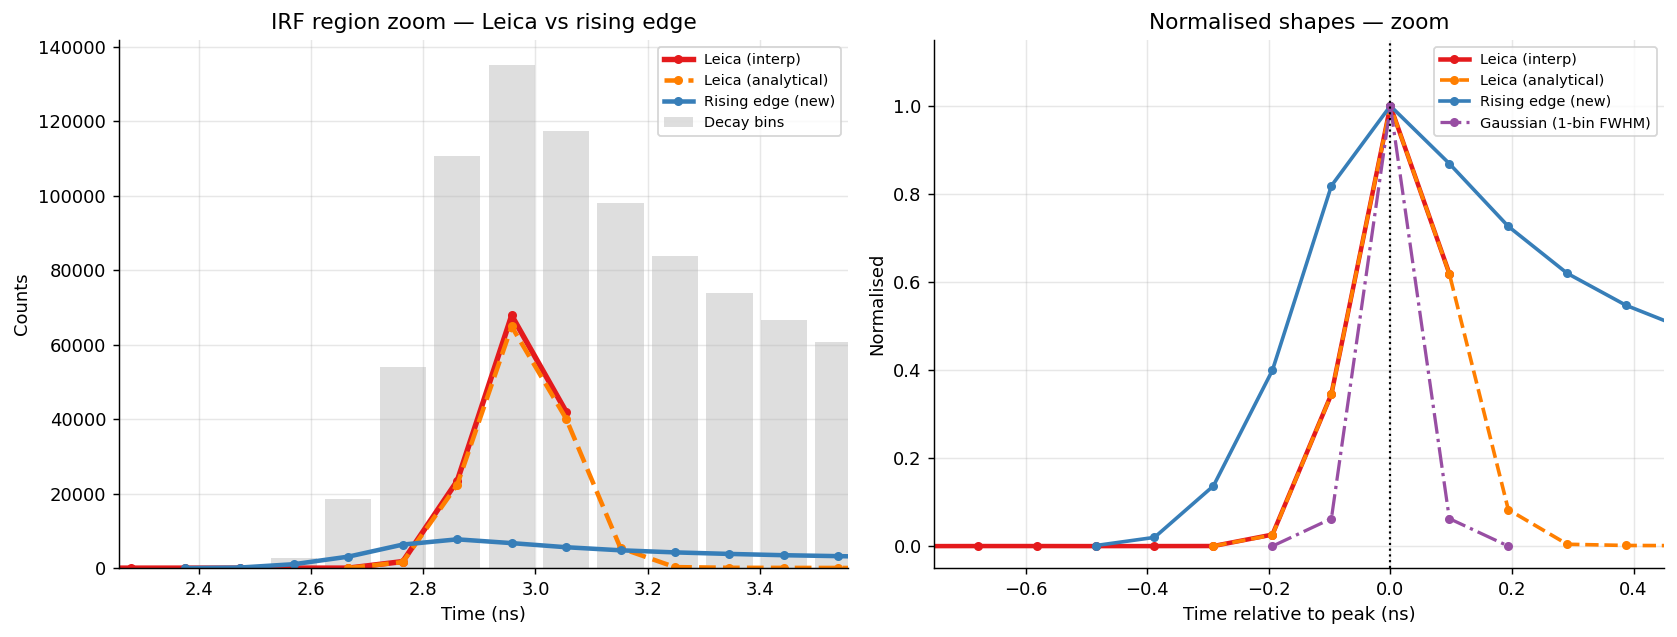

In [37]:
# ── Zoom on IRF region — absolute time axis ───────────────────────────────────
ref_irf = irfs.get('Leica (interp)', list(irfs.values())[0])
pi_ref  = np.argmax(ref_irf)
t_lo    = t_ns[pi_ref] - 0.7
t_hi    = t_ns[pi_ref] + 0.6

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
mask_d = (t_ns >= t_lo) & (t_ns <= t_hi)
ax.bar(t_ns[mask_d], decay[mask_d], width=BW * 0.85,
       color='#d0d0d0', alpha=0.7, label='Decay bins', align='center')
for label in ['Leica (interp)', 'Leica (analytical)', 'Rising edge (new)']:
    if label not in irfs: continue
    irf = irfs[label]
    col = colors[label]; ls, lw = styles[label]
    nz  = irf > 1e-6
    ax.plot(t_ns[nz], irf[nz] * decay.max(),
            ls=ls, lw=lw+0.5, color=col, marker='o', ms=4, label=label)
ax.set_xlim(t_lo, t_hi)
ax.set_xlabel('Time (ns)'); ax.set_ylabel('Counts')
ax.set_title('IRF region zoom — Leica vs rising edge')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for label in ['Leica (interp)', 'Leica (analytical)', 'Rising edge (new)', 'Gaussian (1-bin FWHM)']:
    if label not in irfs: continue
    irf = irfs[label]; pi = np.argmax(irf)
    col = colors[label]; ls, lw = styles[label]
    t_rel = t_ns - t_ns[pi]
    nz = irf > 1e-6
    ax2.plot(t_rel[nz], irf[nz] / irf[pi],
             ls=ls, lw=lw, color=col, marker='o', ms=4, label=label)
ax2.axvline(0, color='k', ls=':', lw=1.2)
ax2.set_xlim(-0.75, 0.45); ax2.set_ylim(-0.05, 1.15)
ax2.set_xlabel('Time relative to peak (ns)'); ax2.set_ylabel('Normalised')
ax2.set_title('Normalised shapes — zoom')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('irf_zoom.png', dpi=150, bbox_inches='tight')
plt.show()


In [38]:
# ── Export the reconstructed IRF for use in fitting ───────────────────────────
out_path = PTU_FILE.with_suffix('.irf.npy')
np.save(out_path, irfs['Rising edge (new)'])
print(f"IRF saved: {out_path}")
print(f"  Shape: {irfs['Rising edge (new)'].shape}")
print(f"  Sum:   {irfs['Rising edge (new)'].sum():.6f}  (should be 1.0)")
print(f"\nLoad in fitting cell with:")
print(f"  irf = np.load('{out_path}')")


IRF saved: /Users/as-hunt/Downloads/2026_02_27_10_38_30--More_to_test/PTU.sptw/well4-FOV1-40x-ado-t20.irf.npy
  Shape: (532,)
  Sum:   1.000000  (should be 1.0)

Load in fitting cell with:
  irf = np.load('/Users/as-hunt/Downloads/2026_02_27_10_38_30--More_to_test/PTU.sptw/well4-FOV1-40x-ado-t20.irf.npy')


## Interpretation guide

| Residual RMS | Assessment |
|---|---|
| < 2% | Excellent — methods are essentially equivalent |
| 2–5% | Good — minor shape differences, likely negligible for fitting |
| 5–15% | Moderate — check BaP and σ QC; may affect short-lifetime components |
| > 15% | Poor — inspect zoom plot; rising edge detection may have failed |

**If rising edge (new) RMS is < 5% vs Leica (interp):**  
The algorithm is working correctly. Use `reconstruct_irf_from_decay()` per tile
in the FLIMKit fitting pipeline — no XLSX export needed.

**If σ falls outside both clusters (narrow 0.092–0.110 ns, wide 0.118–0.132 ns):**  
Check the tile photon count — very low-count tiles may have a noisy rising edge.
Consider falling back to `irf_from_xlsx_analytical` for those tiles.

**Why not the Gaussian (1-bin FWHM)?**  
The Gaussian with FWHM = 1 bin (≈ 97 ps) gives σ ≈ 41 ps, which is 2–3× narrower
than the true IRF (σ = 97–128 ps). This is why χ²_r was 10–50 with the old approach.
